# Planograma OXXO — Optimizador GRASP

Notebook de desarrollo incremental para acomodar productos en anaqueles tipo OXXO.

---

## Bugs corregidos respecto a `grasp_planograma.py`

| # | Bug | Corrección aplicada |
|---|-----|---------------------|
| 1 | `alto` siempre `None` — restricción de altura nunca se aplica | Se lee columna `ALTO` del CSV por producto |
| 2 | `SEPARADOR` ignorado — `sep_default = 0.0` global para todos | `SEPARADOR` por producto; se calcula `ancho_ocupado` |
| 3 | CSV de salida sin `SEGMENTO_ID`, `MUEBLE_ID`, `PLANOGRUPO`, `TAMAÑO` | Se agregan desde metadatos del solver |
| 4 | CSV diagnóstico sin `NUM_PRODUCTOS` ni `ES_FACTIBLE`; índice sin nombre | Columnas añadidas + `index.name = "CHAROLA"` |
| 5 | Rutas apuntan a `/mnt/data/` (Google Colab) | Rutas relativas con `pathlib.Path` |
| 6 | `unassigned.remove()` O(n); `sort()` repetido en cada iteración | `set.discard()` O(1); sort único al inicio |
| 7 | `find_product()` escanea todas las charolas O(n) | Índice inverso `{pid: (charola, pos)}` por ronda |

---

## Archivos necesarios

Coloca tus archivos en la carpeta `data/`:

```
data/
  oxxo_1.csv
  Caso de estudio TEC.xlsx
outputs/       ← los CSVs de salida se guardan aquí
```


## 1. Imports y configuración

In [54]:
from __future__ import annotations

import math
import random
from dataclasses import dataclass
from pathlib import Path
from typing import Dict, List, Optional, Tuple

import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import pandas as pd
import warnings

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:.3f}".format)

print("Librerías cargadas correctamente.")


Librerías cargadas correctamente.


### Rutas y parámetros del formato

Ajusta `PRODUCTS_PATH`, `SHELVES_PATH` y los parámetros del formato antes de correr el notebook.


In [55]:
# ── Rutas ─────────────────────────────────────────────────────
PRODUCTS_PATH = Path("data/oxxo_1.csv")
SHELVES_PATH  = Path("data/Caso de estudio TEC.xlsx")
OUTPUTS_DIR   = Path("outputs")
OUTPUTS_DIR.mkdir(exist_ok=True)

# ── Formato a resolver ────────────────────────────────────────
# Un "formato" = SEGMENTO_ID + MUEBLE_ID + PLANOGRUPO + TAMAÑO + DIRECCION_LEGO_ID
SEGMENTO    = "HRN"
MUEBLE      = "CF"
PLANOGRUPO  = "Refrescos"
TAMANO      = 5.0
DIRECCION   = "ID"   # "ID" = izq→der  |  "DI" = der→izq

# ── Parámetros GRASP ──────────────────────────────────────────
MAX_ITER     = 20    # iteraciones GRASP totales
ALPHA        = 0.2   # RCL: 0=greedy puro, 1=random puro
LOCAL_ROUNDS = 20    # rondas de búsqueda local por iteración
SEED         = 42

print(f"Formato  : {SEGMENTO} | {MUEBLE} | {PLANOGRUPO} | T={TAMANO} | {DIRECCION}")
print(f"Productos: {PRODUCTS_PATH}  existe={PRODUCTS_PATH.exists()}")
print(f"Charolas : {SHELVES_PATH}  existe={SHELVES_PATH.exists()}")


Formato  : HRN | CF | Refrescos | T=5.0 | ID
Productos: data/oxxo_1.csv  existe=True
Charolas : data/Caso de estudio TEC.xlsx  existe=True


## 2. Carga de datos

Maneja encodings variados (UTF-8, UTF-8-BOM, Latin-1) y normaliza nombres de columnas
con caracteres especiales (BOM `\ufeff`, tildes en `TAMAÑO_POST`).


In [56]:
def clean_columns(df: pd.DataFrame) -> pd.DataFrame:
    # Normaliza nombres de columnas: elimina BOM, arregla tildes
    rename = {}
    for c in df.columns:
        c2 = str(c).replace("﻿", "").replace("ï»¿", "").strip()
        c2 = c2.replace("TAMAÃ\x91O_POST", "TAMAÑO_POST")
        c2 = c2.replace("TAMAÃ'O_POST",    "TAMAÑO_POST")
        c2 = c2.replace("TAMANO_POST",     "TAMAÑO_POST")
        c2 = c2.replace("TAMANO",          "TAMAÑO")
        rename[c] = c2
    return df.rename(columns=rename)


def read_csv_safe(path: Path) -> pd.DataFrame:
    # Intenta UTF-8-BOM primero (el más común en Excel-exportados)
    for enc in ("utf-8-sig", "utf-8", "latin1"):
        try:
            return clean_columns(pd.read_csv(path, encoding=enc))
        except UnicodeDecodeError:
            continue
    return clean_columns(pd.read_csv(path))


def read_products(path: Path) -> pd.DataFrame:
    df = read_csv_safe(path)
    required = [
        "SEGMENTO_ID", "MUEBLE_ID", "PLANOGRUPO", "TAMAÑO",
        "DIRECCION_LEGO_ID", "UPC_CVE", "NUM_FRENTES",
        "CHAROLA", "UBICACION_BANDEJA", "ANCHO",
    ]
    missing = [c for c in required if c not in df.columns]
    if missing:
        print(f"⚠️  Columnas faltantes en productos: {missing}")
    else:
        print(f"✅ Productos cargados: {df.shape[0]} filas, {df.shape[1]} columnas")
    optional = ["ALTO", "SEPARADOR"]
    present  = [c for c in optional if c in df.columns]
    absent   = [c for c in optional if c not in df.columns]
    if present:
        print(f"   Columnas opcionales presentes  : {present}")
    if absent:
        print(f"   Columnas opcionales ausentes   : {absent} (se usarán defaults)")
    return df


def read_shelves(path: Path) -> pd.DataFrame:
    df = pd.read_excel(path)
    df = clean_columns(df)
    required = [
        "PLANOGRUPO", "MUEBLE_ID", "TAMAÑO_POST",
        "DIRECCION_LEGO_ID", "CHAROLA", "Width", "Height", "X", "Y",
    ]
    missing = [c for c in required if c not in df.columns]
    if missing:
        print(f"⚠️  Columnas faltantes en charolas: {missing}")
    else:
        print(f"✅ Charolas cargadas: {df.shape[0]} filas, {df.shape[1]} columnas")
    return df


In [57]:
products_df = read_products(PRODUCTS_PATH)
shelves_df  = read_shelves(SHELVES_PATH)


✅ Productos cargados: 32350 filas, 10 columnas
   Columnas opcionales ausentes   : ['ALTO', 'SEPARADOR'] (se usarán defaults)
✅ Charolas cargadas: 2112 filas, 9 columnas


## 3. Exploración de datos

In [58]:
print("=== PRODUCTOS — primeras filas ===")
display(products_df.head(3))


=== PRODUCTOS — primeras filas ===


,SEGMENTO_ID,MUEBLE_ID,PLANOGRUPO,TAMAÑO,DIRECCION_LEGO_ID,UPC_CVE,NUM_FRENTES,CHAROLA,UBICACION_BANDEJA,ANCHO
0,BCO,CF,Alternativas,0.500,DI,7503041640233,1.000,2,4,6.800
1,BCO,CF,Alternativas,0.500,DI,7500464706355,1.000,4,8,5.800
2,BCO,CF,Alternativas,0.500,ID,7501125104268,1.000,3,5,6.500


In [59]:
print("=== FORMATOS disponibles en productos ===")
formatos = (
    products_df
    .groupby(["SEGMENTO_ID", "MUEBLE_ID", "PLANOGRUPO", "TAMAÑO", "DIRECCION_LEGO_ID"])
    .size()
    .reset_index(name="n_productos")
)
display(formatos)


=== FORMATOS disponibles en productos ===


,SEGMENTO_ID,MUEBLE_ID,PLANOGRUPO,TAMAÑO,DIRECCION_LEGO_ID,n_productos
0,BCO,CF,Alternativas,0.500,DI,32
1,BCO,CF,Alternativas,0.500,ID,32
2,BCO,CF,Alternativas,1.000,DI,55
3,BCO,CF,Alternativas,1.000,ID,55
4,BCO,CF,Alternativas,1.500,DI,78
...,...,...,...,...,...,...
310,STD,GC,Botanas,3.000,DI,81
311,STD,GC,Botanas,5.000,DI,137
312,STD,GC,Botanas,5.000,ID,137
313,STD,GC,Botanas,6.000,DI,151


In [60]:
print("=== CHAROLAS — primeras filas ===")
display(shelves_df.head(5))


=== CHAROLAS — primeras filas ===


,PLANOGRUPO,MUEBLE_ID,TAMAÑO_POST,DIRECCION_LEGO_ID,CHAROLA,Width,Height,X,Y
0,Botanas,GC,5.000,DI,1,91.000,1.000,0,10.000
1,Botanas,GC,1.000,DI,1,91.000,1.000,0,9.000
2,Jugos,CF,1.000,DI,1,55.000,2.500,0,0.000
3,Refrescos,CF,3.000,DI,1,55.000,2.500,0,0.000
4,Refrescos,CF,4.500,DI,1,55.000,2.500,0,0.000


## 4. Filtrado por formato

Un **formato** es la combinación única:
`SEGMENTO_ID + MUEBLE_ID + PLANOGRUPO + TAMAÑO + DIRECCION_LEGO_ID`

Cada formato se resuelve de forma independiente.


In [61]:
prod_fmt = products_df[
    (products_df["SEGMENTO_ID"].astype(str)         == str(SEGMENTO))
    & (products_df["MUEBLE_ID"].astype(str)         == str(MUEBLE))
    & (products_df["PLANOGRUPO"].astype(str)        == str(PLANOGRUPO))
    & (products_df["TAMAÑO"].astype(float)          == float(TAMANO))
    & (products_df["DIRECCION_LEGO_ID"].astype(str) == str(DIRECCION))
].copy().reset_index(drop=True)

shelf_fmt = shelves_df[
    (shelves_df["MUEBLE_ID"].astype(str)            == str(MUEBLE))
    & (shelves_df["PLANOGRUPO"].astype(str)         == str(PLANOGRUPO))
    & (shelves_df["TAMAÑO_POST"].astype(float)      == float(TAMANO))
    & (shelves_df["DIRECCION_LEGO_ID"].astype(str)  == str(DIRECCION))
].copy().reset_index(drop=True)

print(f"Productos filtrados : {len(prod_fmt)}")
print(f"Charolas filtradas  : {len(shelf_fmt)}")

# Diagnóstico de factibilidad global (incluyendo separador si existe)
sep_col = prod_fmt["SEPARADOR"] if "SEPARADOR" in prod_fmt.columns else pd.Series(0.0, index=prod_fmt.index)
total_ancho = (prod_fmt["ANCHO"] * prod_fmt["NUM_FRENTES"] + sep_col).sum()
total_cap   = shelf_fmt["Width"].sum()
holgura     = total_cap - total_ancho

print(f"\nAncho total productos : {total_ancho:.2f} cm")
print(f"Capacidad charolas    : {total_cap:.2f} cm")
print(f"Holgura global        : {holgura:.2f} cm  {'✅ factible' if holgura >= 0 else '❌ NO FACTIBLE'}")


Productos filtrados : 147
Charolas filtradas  : 30

Ancho total productos : 1453.60 cm
Capacidad charolas    : 1650.00 cm
Holgura global        : 196.40 cm  ✅ factible


## 5. Estructuras de datos

### FIX 1 — `alto`
El campo `alto` en `Product` ahora se alimenta de la columna `ALTO` del CSV.
Antes siempre era `None`, por lo que `can_fit_at_end()` nunca rechazaba un producto por altura.

### FIX 2 — `separador` / `ancho_ocupado`
Se añaden dos campos nuevos a `Product`:
- `separador`: valor leído de la columna `SEPARADOR` (default 0 si no existe).
- `ancho_ocupado = width_total + separador`: espacio real que consume el producto en la charola.

Todos los cálculos de ancho ahora usan `ancho_ocupado` en lugar de `width_total + sep_default`.


In [62]:
@dataclass(frozen=True)
class Product:
    id: int
    upc: str
    ancho: float
    num_frentes: float
    width_total: float        # ANCHO × NUM_FRENTES  (ancho visual)
    separador: float          # FIX 2: por producto, no global
    ancho_ocupado: float      # FIX 2: width_total + separador (espacio real)
    hist_charola: int
    hist_pos: int
    alto: Optional[float]     # FIX 1: leído del CSV (None si no existe)
    # Modelo 2 — defaults hasta tener datos reales
    peso: float = 0.0
    grupo: str = ""
    categoria: str = ""
    demanda: float = 1.0
    ganancia: float = 1.0
    rotacion: float = 1.0
    promo: float = 0.0
    estacional: float = 1.0


@dataclass(frozen=True)
class Shelf:
    charola: int
    width: float
    height: float
    x_abs_base: float
    y: float
    visibility: float = 1.0   # proxy: charola más alta = más visible


Solution = Dict[int, List[int]]   # charola_id -> [product_id, ...]

print("Dataclasses definidos ✅")


Dataclasses definidos ✅


## 6. Algoritmo GRASP

### FIX 3 — Columnas de salida
`decode()` ahora agrega `SEGMENTO_ID`, `MUEBLE_ID`, `PLANOGRUPO`, `TAMAÑO`, `DIRECCION_LEGO_ID`.

### FIX 6 — Performance en construcción
- El sort de productos se hace **una sola vez** al inicio (antes se repetía en cada iteración).
- `set.discard()` en lugar de `list.remove()` para quitar productos asignados en O(1).

### FIX 7 — `find_product` con índice inverso
Se construye un dict `{pid: (charola, posición)}` una vez por ronda de búsqueda local,
evitando el escaneo lineal de todas las charolas por cada movimiento.


In [63]:
class GRASPPlanograma:

    def __init__(
        self,
        products: List[Product],
        shelves: List[Shelf],
        direction: str,
        # FIX 3: metadatos del formato para el CSV de salida
        segmento: str = "",
        mueble: str = "",
        planogrupo: str = "",
        tamano: float = 0.0,
        # parámetros del algoritmo
        alpha: float = 0.2,
        lambda_hist: float = 1.0,
        beta_visibility: float = 0.10,
        random_seed: int = 42,
    ):
        self.products    = {p.id: p for p in products}
        self.shelves     = {s.charola: s for s in shelves}
        self.charolas    = sorted(self.shelves)
        self.direction   = direction.upper().strip()
        self.segmento    = segmento
        self.mueble      = mueble
        self.planogrupo  = planogrupo
        self.tamano      = tamano
        self.alpha           = alpha
        self.lambda_hist     = lambda_hist
        self.beta_visibility = beta_visibility
        self.rng = random.Random(random_seed)

    # ── Helpers de ancho ─────────────────────────────────────────────────────

    def used_width(self, sol: Solution, c: int) -> float:
        # FIX 2: ancho_ocupado incluye separador por producto
        return sum(self.products[i].ancho_ocupado for i in sol.get(c, []))

    def can_fit_at_end(self, sol: Solution, pid: int, c: int) -> bool:
        p = self.products[pid]
        s = self.shelves[c]
        # FIX 1: restricción de altura solo si alto está definido
        if p.alto is not None and p.alto > s.height:
            return False
        # FIX 2: usar ancho_ocupado
        return self.used_width(sol, c) + p.ancho_ocupado <= s.width + 1e-9

    # ── Decodificador ────────────────────────────────────────────────────────

    def decode(self, sol: Solution) -> pd.DataFrame:
        rows = []
        for c in self.charolas:
            shelf  = self.shelves[c]
            cursor = 0.0
            for pos, pid in enumerate(sol.get(c, []), start=1):
                p = self.products[pid]
                w = p.width_total    # ancho visual del producto
                if self.direction == "ID":
                    x_local = cursor
                else:                # DI: derecha a izquierda
                    x_local = shelf.width - cursor - w
                x_abs = shelf.x_abs_base + x_local
                rows.append({
                    # FIX 3: columnas requeridas por el spec
                    "SEGMENTO_ID":              self.segmento,
                    "MUEBLE_ID":                self.mueble,
                    "PLANOGRUPO":               self.planogrupo,
                    "TAMAÑO":                   self.tamano,
                    "DIRECCION_LEGO_ID":        self.direction,
                    "UPC_CVE":                  p.upc,
                    "CHAROLA":                  c,
                    "UBICACION_BANDEJA":        pos,
                    "X_LOCAL":                  round(x_local, 4),
                    "X_ABS":                    round(x_abs, 4),
                    "X_FIN_LOCAL":              round(x_local + w, 4),
                    "Y":                        shelf.y,
                    "NUM_FRENTES":              p.num_frentes,
                    "ANCHO":                    p.ancho,
                    "ANCHO_TOTAL":              round(w, 4),
                    "SEPARADOR":                p.separador,
                    "ANCHO_OCUPADO":            round(p.ancho_ocupado, 4),
                    "HIST_CHAROLA":             p.hist_charola,
                    "HIST_UBICACION_BANDEJA":   p.hist_pos,
                })
                # FIX 2: cursor avanza con ancho_ocupado (incluye separador)
                cursor += p.ancho_ocupado
        return pd.DataFrame(rows)

    # ── Factibilidad ─────────────────────────────────────────────────────────

    def feasible(self, sol: Solution) -> bool:
        assigned = [pid for c in self.charolas for pid in sol.get(c, [])]
        if len(assigned) != len(set(assigned)):
            return False   # duplicados
        if set(assigned) != set(self.products):
            return False   # faltan o sobran productos
        for c in self.charolas:
            if self.used_width(sol, c) > self.shelves[c].width + 1e-9:
                return False   # charola excede capacidad
        return True

    # ── Función objetivo ─────────────────────────────────────────────────────

    def objective(self, sol: Solution) -> float:
        # Usa el diccionario de solución directamente (evita decodificar a DataFrame)
        position_map: Dict[int, Tuple[int, int]] = {}
        for c, pids in sol.items():
            for pos, pid in enumerate(pids, start=1):
                position_map[pid] = (c, pos)

        score = 0.0
        for pid, p in self.products.items():
            c, pos  = position_map.get(pid, (p.hist_charola, p.hist_pos))
            shelf   = self.shelves.get(c, self.shelves[self.charolas[0]])
            vx      = p.demanda * p.ganancia * p.rotacion * p.estacional * (1.0 + p.promo)
            score  += self.beta_visibility * vx * shelf.visibility
            score  -= self.lambda_hist * (abs(c - p.hist_charola) + 0.15 * abs(pos - p.hist_pos))
        return score

    def incremental_score(self, pid: int, c: int, pos: int) -> float:
        p     = self.products[pid]
        shelf = self.shelves[c]
        vx    = p.demanda * p.ganancia * p.rotacion * p.estacional * (1.0 + p.promo)
        s     = self.beta_visibility * vx * shelf.visibility
        s    -= self.lambda_hist * (abs(c - p.hist_charola) + 0.15 * abs(pos - p.hist_pos))
        if c == p.hist_charola:
            s += 0.5   # bono por coincidir con charola histórica
        return s

    # ── Índice inverso O(1) ──────────────────────────────────────────────────

    def _build_inv(self, sol: Solution) -> Dict[int, Tuple[int, int]]:
        # FIX 7: {pid: (charola, posición_en_lista)} — evita escaneo lineal
        return {pid: (c, i) for c, lst in sol.items() for i, pid in enumerate(lst)}

    # ── Construcción GRASP ───────────────────────────────────────────────────

    def construct(self) -> Solution:
        sol: Solution = {c: [] for c in self.charolas}

        # FIX 6: sort único al inicio — más ancho_ocupado primero, luego histórico
        priority = sorted(
            self.products.keys(),
            key=lambda pid: (
                -self.products[pid].ancho_ocupado,
                self.products[pid].hist_charola,
                self.products[pid].hist_pos,
            ),
        )
        unassigned: set = set(priority)

        while unassigned:
            pid_actual = next(p for p in priority if p in unassigned)

            candidates: List[Tuple[int, int, float]] = [
                (pid_actual, c, self.incremental_score(pid_actual, c, len(sol[c]) + 1))
                for c in self.charolas
                if self.can_fit_at_end(sol, pid_actual, c)
            ]

            if not candidates:
                raise RuntimeError(
                    f"Sin charola factible para producto {pid_actual} "
                    f"(ancho_ocupado={self.products[pid_actual].ancho_ocupado:.2f} cm). "
                    "Revisa anchos, separadores o capacidad."
                )

            g_vals    = [g for _, _, g in candidates]
            g_max, g_min = max(g_vals), min(g_vals)
            threshold = g_max - self.alpha * (g_max - g_min)
            rcl       = [(pid, c, g) for pid, c, g in candidates if g >= threshold]
            pid, c, _ = self.rng.choice(rcl)
            sol[c].append(pid)
            unassigned.discard(pid)   # FIX 6: O(1)

        return sol

    # ── Búsqueda local ───────────────────────────────────────────────────────

    def local_search(
        self, sol: Solution, max_rounds: int = 30, sample_moves: int = 250
    ) -> Solution:
        best       = {c: list(v) for c, v in sol.items()}
        best_score = self.objective(best)
        pids       = list(self.products.keys())

        for _ in range(max_rounds):
            improved       = False
            best_neighbor  = None
            best_nbr_score = best_score

            inv = self._build_inv(best)   # FIX 7: índice por ronda

            for _ in range(sample_moves):
                move = self.rng.choice(["swap", "relocate"])
                cand = {c: list(v) for c, v in best.items()}

                if move == "swap":
                    i, j   = self.rng.sample(pids, 2)
                    ci, pi = inv[i]
                    cj, pj = inv[j]
                    cand[ci][pi], cand[cj][pj] = cand[cj][pj], cand[ci][pi]
                else:
                    i      = self.rng.choice(pids)
                    ci, pi = inv[i]
                    cand[ci].pop(pi)
                    c_dest = self.rng.choice(self.charolas)
                    ins    = self.rng.randint(0, len(cand[c_dest]))
                    cand[c_dest].insert(ins, i)

                if not self.feasible(cand):
                    continue
                score = self.objective(cand)
                if score > best_nbr_score + 1e-9:
                    best_nbr_score = score
                    best_neighbor  = cand

            if best_neighbor is not None:
                best       = best_neighbor
                best_score = best_nbr_score
                improved   = True

            if not improved:
                break

        return best

    # ── Loop principal ───────────────────────────────────────────────────────

    def run(self, max_iter: int = 20, local_rounds: int = 20) -> Tuple[Solution, float]:
        best_sol   = None
        best_score = -math.inf
        for it in range(1, max_iter + 1):
            sol   = self.construct()
            sol   = self.local_search(sol, max_rounds=local_rounds)
            score = self.objective(sol)
            if self.feasible(sol) and score > best_score:
                best_sol, best_score = sol, score
            print(f"  Iter {it:3d}/{max_iter} | score={score:+.4f} | best={best_score:+.4f}", end="\r")
        print()
        if best_sol is None:
            raise RuntimeError("No se encontró ninguna solución factible.")
        return best_sol, best_score


print("GRASPPlanograma definido ✅")


GRASPPlanograma definido ✅


## 7. Construcción de instancia

Convierte los DataFrames filtrados en listas de `Product` y `Shelf`.

- **FIX 1**: Lee `ALTO` si existe en el DataFrame.
- **FIX 2**: Lee `SEPARADOR` por producto; calcula `ancho_ocupado`.
- **FIX 3**: Pasa los metadatos del formato al solver.


In [64]:
def build_instance(
    pf: pd.DataFrame,
    sf: pd.DataFrame,
    segmento: str,
    mueble: str,
    planogrupo: str,
    tamano: float,
    direccion: str,
) -> Tuple[List[Product], List[Shelf]]:

    if pf.empty:
        raise ValueError("No hay productos para ese formato.")
    if sf.empty:
        raise ValueError("No hay charolas para ese formato.")

    # Visibilidad proxy: charola más alta en Y → más visible (para el objetivo)
    y_min, y_max = sf["Y"].min(), sf["Y"].max()
    y_range = max(y_max - y_min, 1.0)

    shelves: List[Shelf] = []
    for _, r in sf.sort_values("CHAROLA").iterrows():
        y_norm     = (float(r["Y"]) - y_min) / y_range
        visibility = 1.0 + y_norm
        shelves.append(Shelf(
            charola    = int(r["CHAROLA"]),
            width      = float(r["Width"]),
            height     = float(r["Height"]),
            x_abs_base = float(r.get("X", 0.0)),
            y          = float(r.get("Y", 0.0)),
            visibility = visibility,
        ))

    products: List[Product] = []
    for idx, r in pf.reset_index(drop=True).iterrows():
        ancho   = float(r["ANCHO"])
        frentes = float(r["NUM_FRENTES"])
        w_total = ancho * frentes

        # FIX 1: leer ALTO por producto (None si columna ausente o NaN)
        alto = None
        if "ALTO" in pf.columns and pd.notna(r.get("ALTO")):
            alto = float(r["ALTO"])

        # FIX 2: leer SEPARADOR por producto (0.0 si columna ausente o NaN)
        sep = 0.0
        if "SEPARADOR" in pf.columns and pd.notna(r.get("SEPARADOR")):
            sep = float(r["SEPARADOR"])

        products.append(Product(
            id            = idx,
            upc           = str(r["UPC_CVE"]),
            ancho         = ancho,
            num_frentes   = frentes,
            width_total   = w_total,
            separador     = sep,
            ancho_ocupado = w_total + sep,   # FIX 2
            hist_charola  = int(r["CHAROLA"]),
            hist_pos      = int(r["UBICACION_BANDEJA"]),
            alto          = alto,            # FIX 1
            grupo         = str(r.get("PLANOGRUPO", "")),
            categoria     = str(r.get("categoria_producto", "")),
        ))

    total_ancho = sum(p.ancho_ocupado for p in products)
    total_cap   = sum(s.width for s in shelves)

    print(f"Productos  : {len(products)}")
    print(f"Charolas   : {len(shelves)}")
    print(f"Ancho total: {total_ancho:.2f} cm / Capacidad: {total_cap:.2f} cm")

    if total_ancho > total_cap + 1e-9:
        raise ValueError(
            f"Instancia no factible: ancho={total_ancho:.2f} cm > "
            f"capacidad={total_cap:.2f} cm"
        )
    print("Instancia factible ✅")
    return products, shelves


print("build_instance() definida ✅")


build_instance() definida ✅


## 8. Ejecución del GRASP

In [65]:
products, shelves = build_instance(
    prod_fmt, shelf_fmt,
    SEGMENTO, MUEBLE, PLANOGRUPO, TAMANO, DIRECCION,
)

solver = GRASPPlanograma(
    products    = products,
    shelves     = shelves,
    direction   = DIRECCION,
    segmento    = SEGMENTO,    # FIX 3
    mueble      = MUEBLE,
    planogrupo  = PLANOGRUPO,
    tamano      = TAMANO,
    alpha            = ALPHA,
    random_seed      = SEED,
    lambda_hist      = 1.0,
    beta_visibility  = 0.10,
)

print(f"Corriendo GRASP: {MAX_ITER} iteraciones…")
best_sol, best_score = solver.run(max_iter=MAX_ITER, local_rounds=LOCAL_ROUNDS)
print(f"Score final: {best_score:.4f}")


Productos  : 147
Charolas   : 30
Ancho total: 1453.60 cm / Capacidad: 1650.00 cm
Instancia factible ✅
Corriendo GRASP: 20 iteraciones…
  Iter  20/20 | score=-193.7080 | best=-193.7080
Score final: -193.7080


In [66]:
output_df = solver.decode(best_sol).sort_values(["CHAROLA", "UBICACION_BANDEJA"])
print(f"Productos en solución: {len(output_df)}")
display(output_df.head(10))


Productos en solución: 147


,SEGMENTO_ID,MUEBLE_ID,PLANOGRUPO,TAMAÑO,DIRECCION_LEGO_ID,UPC_CVE,CHAROLA,UBICACION_BANDEJA,X_LOCAL,X_ABS,X_FIN_LOCAL,Y,NUM_FRENTES,ANCHO,ANCHO_TOTAL,SEPARADOR,ANCHO_OCUPADO,HIST_CHAROLA,HIST_UBICACION_BANDEJA
0,HRN,CF,Refrescos,5.000,ID,21136010541,1,1,0.000,0.000,7.800,0.000,1.000,7.800,7.800,0.000,7.800,4,4
1,HRN,CF,Refrescos,5.000,ID,7500326103438,1,2,7.800,7.800,17.300,0.000,1.000,9.500,9.500,0.000,9.500,2,2
2,HRN,CF,Refrescos,5.000,ID,7501073839861,2,1,0.000,0.000,10.300,42.000,1.000,10.300,10.300,0.000,10.300,2,5
3,HRN,CF,Refrescos,5.000,ID,21136010480,2,2,10.300,10.300,20.000,42.000,1.000,9.700,9.700,0.000,9.700,1,2
4,HRN,CF,Refrescos,5.000,ID,7501071120176,2,3,20.000,20.000,29.000,42.000,1.000,9.000,9.000,0.000,9.000,1,4
5,HRN,CF,Refrescos,5.000,ID,7501073840843,2,4,29.000,29.000,39.300,42.000,1.000,10.300,10.300,0.000,10.300,1,5
6,HRN,CF,Refrescos,5.000,ID,7501073830028,2,5,39.300,39.300,47.300,42.000,1.000,8.000,8.000,0.000,8.000,3,3
7,HRN,CF,Refrescos,5.000,ID,7500326103476,2,6,47.300,47.300,54.500,42.000,1.000,7.200,7.200,0.000,7.200,3,6
8,HRN,CF,Refrescos,5.000,ID,7501071120190,3,1,0.000,0.000,8.300,84.000,1.000,8.300,8.300,0.000,8.300,3,1
9,HRN,CF,Refrescos,5.000,ID,7501073800908,3,2,8.300,8.300,18.600,84.000,1.000,10.300,10.300,0.000,10.300,1,1


## 9. Diagnóstico y exportación

### FIX 4 — CSV diagnóstico completo
Se agregan `NUM_PRODUCTOS` y `ES_FACTIBLE`. El índice ahora se llama `CHAROLA`.

### FIX 5 — Rutas relativas
Los CSVs se guardan en `outputs/` relativo al proyecto.


In [67]:
# Diagnóstico por charola
used_w    = output_df.groupby("CHAROLA")["ANCHO_OCUPADO"].sum().rename("ANCHO_USADO")
capacity  = pd.Series({s.charola: s.width for s in shelves}, name="ANCHO_CAPACIDAD")
num_prods = output_df.groupby("CHAROLA")["UPC_CVE"].count().rename("NUM_PRODUCTOS")

diag = pd.concat([used_w, capacity, num_prods], axis=1)
diag.index.name = "CHAROLA"                      # FIX 4: índice con nombre
diag["HOLGURA"]     = diag["ANCHO_CAPACIDAD"] - diag["ANCHO_USADO"]
diag["ES_FACTIBLE"] = diag["HOLGURA"] >= -1e-9   # FIX 4

print(f"Charolas factibles: {diag['ES_FACTIBLE'].sum()} / {len(diag)}")
print(f"Holgura mínima    : {diag['HOLGURA'].min():.4f} cm")
display(diag)


Charolas factibles: 30 / 30
Holgura mínima    : 0.0000 cm


,ANCHO_USADO,ANCHO_CAPACIDAD,NUM_PRODUCTOS,HOLGURA,ES_FACTIBLE
CHAROLA,,,,,
1,17.300,55.000,2,37.700,True
2,54.500,55.000,6,0.500,True
3,44.750,55.000,5,10.250,True
4,52.000,55.000,6,3.000,True
5,46.100,55.000,6,8.900,True
6,55.000,55.000,4,0.000,True
7,44.300,55.000,6,10.700,True
8,43.950,55.000,4,11.050,True
9,54.900,55.000,8,0.100,True


In [68]:
fmt_tag   = f"{SEGMENTO}_{MUEBLE}_{PLANOGRUPO}_{int(TAMANO)}_{DIRECCION}"
out_path  = OUTPUTS_DIR / f"salida_grasp_{fmt_tag}.csv"
diag_path = OUTPUTS_DIR / f"salida_grasp_{fmt_tag}_diagnostico.csv"

output_df.to_csv(out_path,  index=False, encoding="utf-8-sig")
diag.to_csv(diag_path, encoding="utf-8-sig")   # index=True para exportar CHAROLA

print(f"✅ Salida guardada     : {out_path}")
print(f"✅ Diagnóstico guardado: {diag_path}")


✅ Salida guardada     : outputs/salida_grasp_HRN_CF_Refrescos_5_ID.csv
✅ Diagnóstico guardado: outputs/salida_grasp_HRN_CF_Refrescos_5_ID_diagnostico.csv


## 10. Visualización 2D del planograma

Cada rectángulo = un producto.
- **Ancho** = `ANCHO_TOTAL` (cm)
- **Alto** = altura de la charola (referencia visual)
- **Posición** = determinada por `X_LOCAL` y `Y`
- Los colores diferencian productos distintos
- Las etiquetas muestran los últimos 5 dígitos del UPC


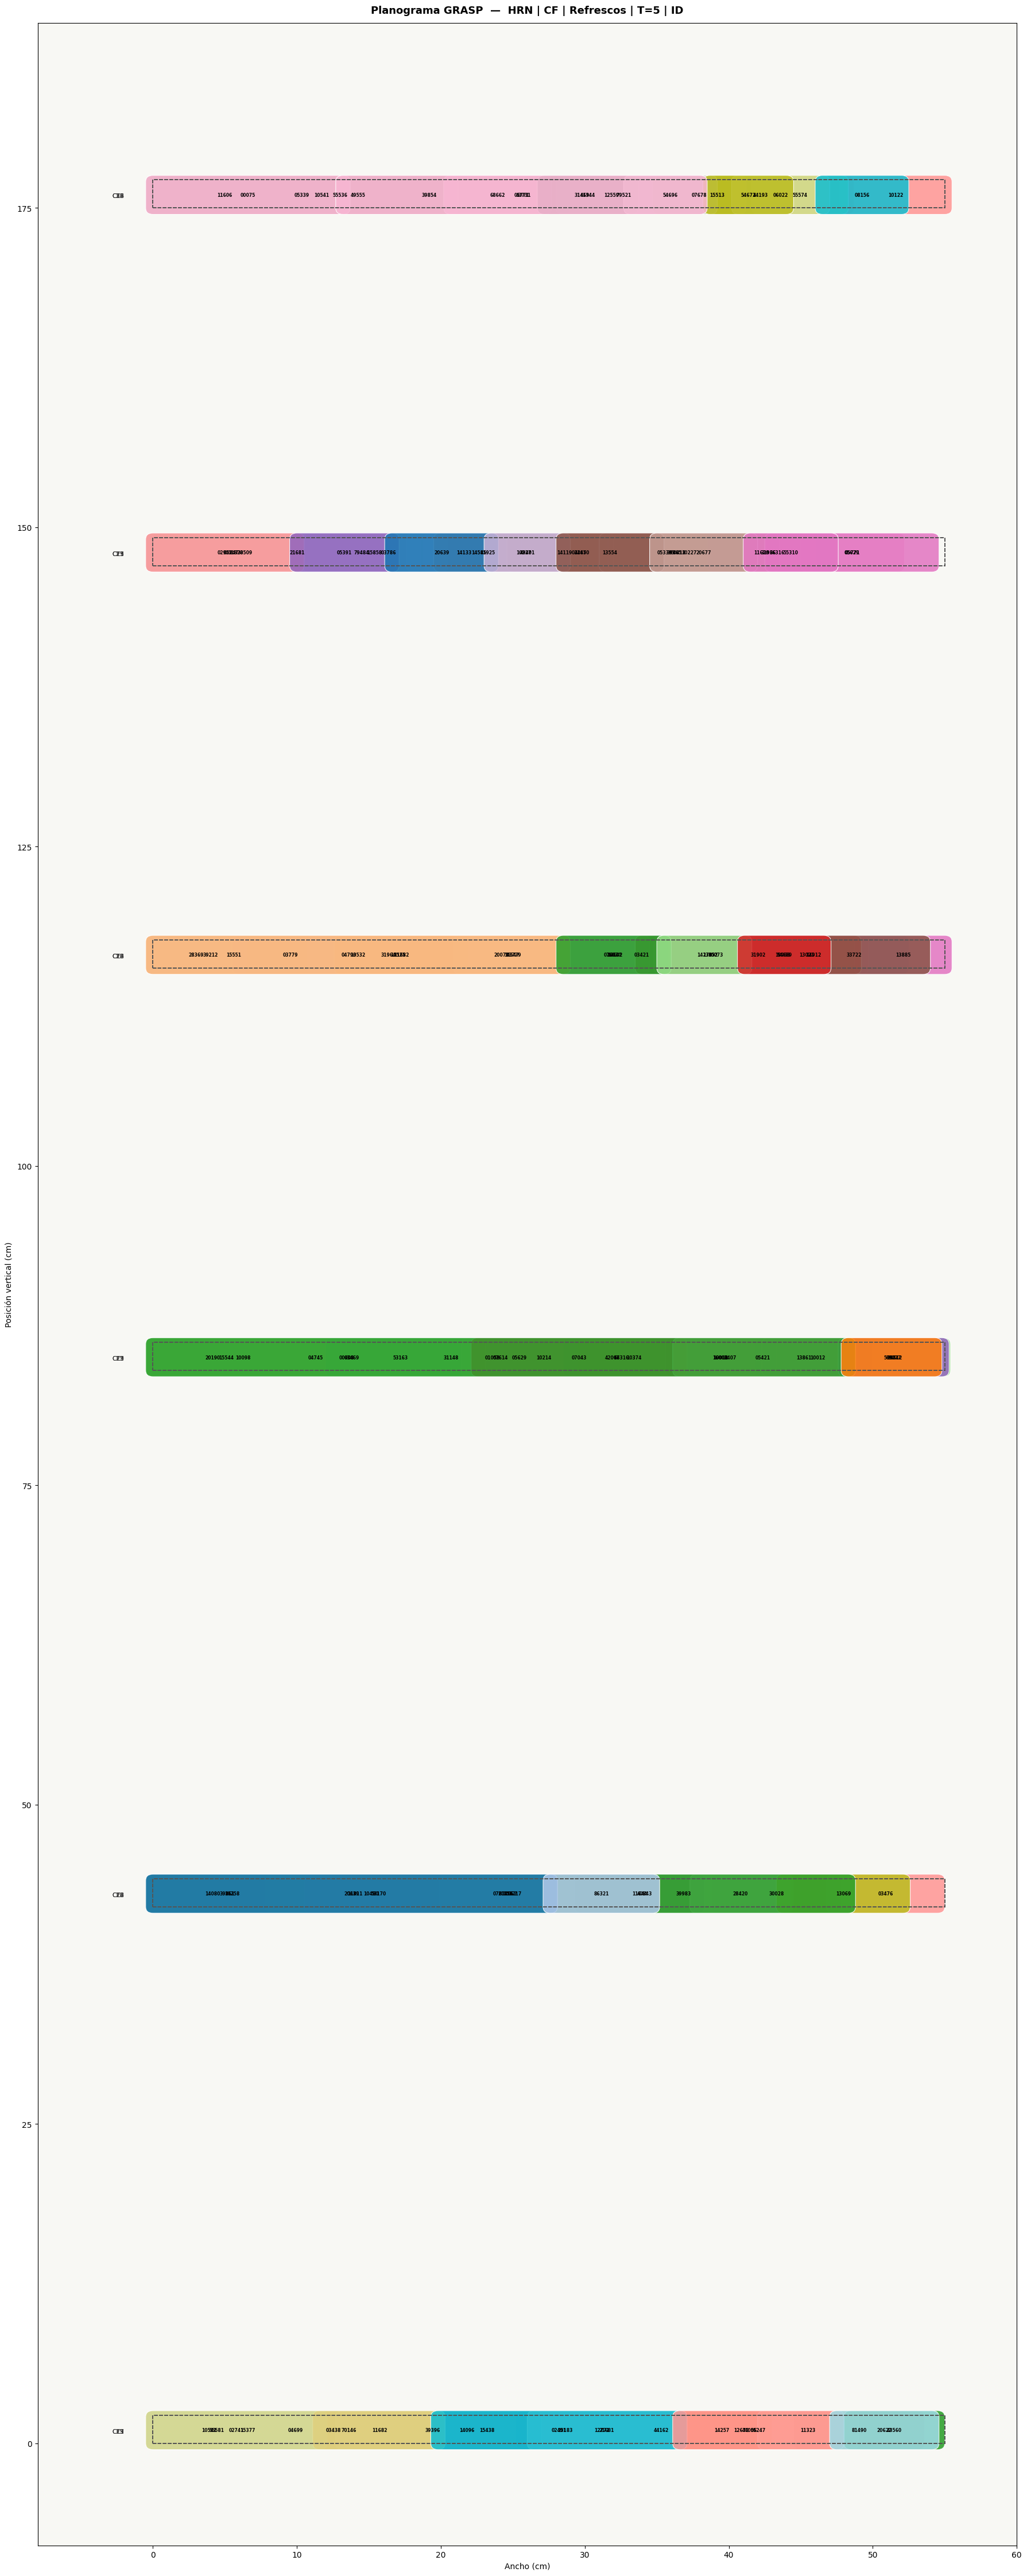

In [69]:
def plot_planograma(
    output_df: pd.DataFrame,
    shelves: List[Shelf],
    title: str = "Planograma OXXO — GRASP",
) -> None:
    shelf_map = {s.charola: s for s in shelves}
    upcs      = output_df["UPC_CVE"].unique()
    cmap      = plt.colormaps.get_cmap("tab20")
    color_map = {upc: cmap(i % 20) for i, upc in enumerate(upcs)}

    fig_h = max(6, len(shelf_map) * 1.5)
    fig, ax = plt.subplots(figsize=(18, fig_h))

    for _, row in output_df.iterrows():
        c       = int(row["CHAROLA"])
        shelf   = shelf_map[c]
        x       = float(row["X_LOCAL"])
        y_base  = float(row["Y"])
        w       = float(row["ANCHO_TOTAL"])
        h       = shelf.height * 0.82
        upc_str = str(row["UPC_CVE"])
        color   = color_map[upc_str]

        rect = mpatches.FancyBboxPatch(
            (x, y_base), w, h,
            boxstyle="round,pad=0.5",
            linewidth=0.8,
            edgecolor="white",
            facecolor=color,
            alpha=0.88,
        )
        ax.add_patch(rect)

        # Etiqueta: últimos 5 dígitos del UPC si hay espacio
        label = upc_str[-5:]
        if w > 4.5:
            ax.text(
                x + w / 2, y_base + h / 2, label,
                ha="center", va="center",
                fontsize=5.5, color="black", fontweight="bold",
            )

    # Bordes de charola y etiqueta lateral
    for s in shelves:
        ax.add_patch(mpatches.Rectangle(
            (0, s.y), s.width, s.height * 0.88,
            fill=False, edgecolor="#555", linewidth=1.2, linestyle="--",
        ))
        ax.text(
            -2, s.y + s.height * 0.38, f"C{s.charola}",
            fontsize=7.5, color="#333", ha="right", va="center",
        )

    total_h = max(s.y + s.height for s in shelves)
    total_w = max(s.width for s in shelves)

    ax.set_xlim(-8, total_w + 5)
    ax.set_ylim(-8, total_h + 12)
    ax.set_xlabel("Ancho (cm)", fontsize=10)
    ax.set_ylabel("Posición vertical (cm)", fontsize=10)
    ax.set_title(title, fontsize=13, fontweight="bold", pad=12)
    ax.set_facecolor("#f8f8f4")
    fig.tight_layout()
    plt.show()


plot_planograma(
    output_df, shelves,
    title=f"Planograma GRASP  —  {SEGMENTO} | {MUEBLE} | {PLANOGRUPO} | T={int(TAMANO)} | {DIRECCION}",
)
